# 실험설계

- 원하는 결과나 한가지 변수에 대한 차이를 보고싶다면 실험 계획을 확실히 하고 들어가는게 좋습니다


# 사용자 정의 루프

- vocasize, model을 리스트 및 딕셔너리로 잡고 for문 두번으로 전체 실험돌리기

- vocab_sizes = [1500, 3000, 5000, 10000, None] # None은 모든 단어 사용  

models = {   
    "Naive Bayes": MultinomialNB(),   
    "Logistic Regression": LogisticRegression(max_iter=1000,    solver='liblinear'),   
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1)   
}



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import reuters
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Reuters 데이터를 텍스트로 복원하는 함수 (CountVectorizer 사용을 위해)
def decode_reuters(x_data):
    word_index = reuters.get_word_index()
    index_to_word = {i+3: word for word, i in word_index.items()}
    for i, word in enumerate(('<pad>', '<sos>', '<unk>')):
        index_to_word[i] = word

    decoded_docs = []
    for sequence in x_data:
        decoded_docs.append(' '.join([index_to_word.get(i, '?') for i in sequence]))
    return decoded_docs

# 2. 실험 설정
vocab_sizes = [1500, 3000, 5000, 10000, None] # None은 모든 단어 사용
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    'Linear SVM': LinearSVC(),
    'Complement NB': ComplementNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

# 3. 실험 루프
for size in vocab_sizes:
    print(f"--- Experimenting with Vocab Size: {size if size else 'All'} ---")

    # 데이터 로드
    (x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=size, test_split=0.2)

    # 텍스트 복원
    x_train_text = decode_reuters(x_train)
    x_test_text = decode_reuters(x_test)

    # TF-IDF 벡터화
    dtmvector = CountVectorizer()
    x_train_dtm = dtmvector.fit_transform(x_train_text)
    x_test_dtm = dtmvector.transform(x_test_text)

    tfidf_transformer = TfidfTransformer()
    x_train_tfidf = tfidf_transformer.fit_transform(x_train_dtm)
    x_test_tfidf = tfidf_transformer.transform(x_test_dtm)

    # 모델별 학습 및 평가
    for name, model in models.items():
        model.fit(x_train_tfidf, y_train)
        predicted = model.predict(x_test_tfidf)

        acc = accuracy_score(y_test, predicted)
        f1 = f1_score(y_test, predicted, average='weighted')

        results.append({
            "Vocab Size": size if size else "Full",
            "Model": name,
            "Accuracy": acc,
            "F1 Score": f1
        })

# 4. 결과 정리
df_results = pd.DataFrame(results)
print("\n[실험 결과 요약]")
print(df_results)

--- Experimenting with Vocab Size: 1500 ---
--- Experimenting with Vocab Size: 3000 ---
--- Experimenting with Vocab Size: 5000 ---
--- Experimenting with Vocab Size: 10000 ---
--- Experimenting with Vocab Size: All ---

[실험 결과 요약]
   Vocab Size                Model  Accuracy  F1 Score
0        1500          Naive Bayes  0.691451  0.642744
1        1500  Logistic Regression  0.794301  0.769610
2        1500        Random Forest  0.773820  0.754081
3        1500           Linear SVM  0.829475  0.822643
4        1500        Complement NB  0.748887  0.718331
5        1500    Gradient Boosting  0.756901  0.752221
6        3000          Naive Bayes  0.687444  0.626617
7        3000  Logistic Regression  0.798753  0.777560
8        3000        Random Forest  0.772039  0.750815
9        3000           Linear SVM  0.829029  0.822879
10       3000        Complement NB  0.764470  0.736972
11       3000    Gradient Boosting  0.762689  0.758896
12       5000          Naive Bayes  0.673197  0.60125

/var/folders/q3/hz0fg47j4_g8nqffrmt9hlc00000gn/T/ipykernel_72605/3153234888.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)


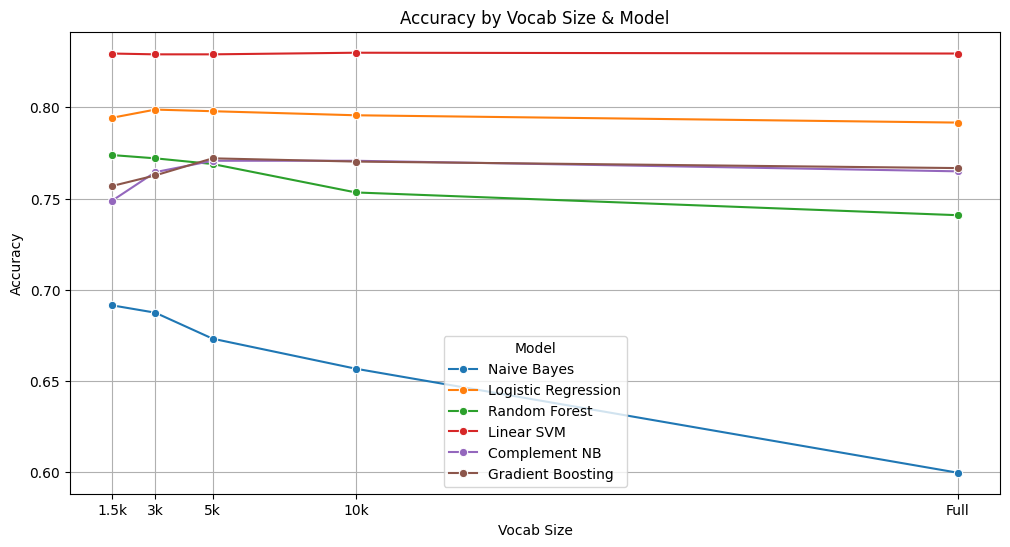

In [4]:
# 1. 에러 수정을 위해 데이터프레임 복사
df_plot = df_results.copy()

# 2. "Full" 문자열을 그래프에 표시될 적당한 숫자(예: 31000)로 변경
# Reuters 전체 단어 수가 대략 3만 개 정도 됩니다.
df_plot['Vocab Size'] = df_plot['Vocab Size'].replace("Full", 31000)

# 3. 데이터 타입을 숫자로 강제 변환 (안전장치)
df_plot['Vocab Size'] = pd.to_numeric(df_plot['Vocab Size'])

# 4. 시각화 다시 실행
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x="Vocab Size", y="Accuracy", hue="Model", marker='o')

# X축 눈금을 예쁘게 만들기 위해 "Full" 위치에 텍스트 표시 (선택 사항)
plt.xticks(ticks=[1500, 3000, 5000, 10000, 31000], labels=['1.5k', '3k', '5k', '10k', 'Full'])

plt.title("Accuracy by Vocab Size & Model")
plt.grid(True)
plt.show()